# Imports and load data

This notebook presents the intra-family distance matrices at sequence level and the impact of subsampling.

In [28]:
import numpy as np
import pandas as pd 
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec 


In [29]:
DATA_PATH = Path("../data/ArchiveII.csv")
# DISTANCE_PATH = Path("../data/ArchiveII_distances.h5")
DISTANCE_PATH = Path("../data/rnadist_f_all.h5")
SUBSAMPLED_PATH = Path("../results/ArchiveII_subsampled_ids.csv")

df_full = pd.read_csv(DATA_PATH, index_col="id")
dist_mat = pd.read_hdf(DISTANCE_PATH, key="rnadist")
df_ids = pd.read_csv(SUBSAMPLED_PATH)

# Data processing and plotting Functions

In [30]:
dist_mat /= dist_mat.to_numpy().max()  # 0 to 1
fams_to_visualize = ["5s", "tRNA", "tmRNA", "RNaseP", "srp"]
strategies = ["sortS", "clusS", "randS"]
K_order = [400, 200, 100]

# get ids per partition
subsampled_ids = {
    partition: group["id"].to_numpy()
    for partition, group in df_ids.groupby("partition")
}

# get ids per strategy and partition
ids_by_strategy = {}
for strategy in strategies:
    ids_by_strategy[strategy] = {"Full": subsampled_ids["full"]}

    # get ids for each partition at each K
    for K in K_order:
        partition = f"{strategy}{K}"
        ids_by_strategy[strategy][partition] = subsampled_ids[partition]
        
# get ids of families to visualize
selected_fams = {
    family: df_full.index[df_full["fam"] == family].tolist()
    for family in fams_to_visualize
}


In [31]:
def sort_matrix_ids(matrix):
    return matrix.mean().sort_values().index

def plot_matrices_sort_ids(selected_fams, ids_subsample, dist_mat, save=False):
    n_rows = len(selected_fams)
    n_cols = len(ids_subsample)
    fig = plt.figure(figsize=(6.5,8))

    gs = gridspec.GridSpec(
        n_rows,
        n_cols + 1,  # colorbar
        width_ratios=[1] * n_cols + [0.05], 
        wspace=0.0,
        hspace=0.15,
    )

    for row_idx, (fam, fam_ids) in enumerate(selected_fams.items()):
        fam_mat = dist_mat.loc[fam_ids, fam_ids]  

        fam_ids = sort_matrix_ids(fam_mat) 
        
        for col_idx, (label, ids_subset) in enumerate(ids_subsample.items()): 
            ids_fam_subset = pd.Index(fam_ids).intersection(ids_subset).tolist() 
            sub_mat = fam_mat.loc[ids_fam_subset, ids_fam_subset] 
 
            ax = fig.add_subplot(gs[row_idx, col_idx])
            im = ax.imshow(sub_mat,  vmin=0, vmax=0.7, cmap="viridis", aspect="equal", )

            if col_idx == 0: 
                ax.set_ylabel(fam, 
                    fontsize=9,
                    rotation=90,
                    ha="right",
                    va="center",
                    labelpad=6,) 
            ax.text(
                0.5, 1.01,
                f"n={len(ids_fam_subset)}",
                transform=ax.transAxes,
                ha="center",
                va="bottom",
                fontsize=7,
            )

            ax.set_xticks([])
            ax.set_yticks([])

    # Colorbar
    cax = fig.add_subplot(gs[:, -1])
    cbar = fig.colorbar(im, cax=cax)

    cbar.ax.tick_params(labelsize=8)
    cbar.set_label("Structural distance", fontsize=9)

    # # colorbar 
    # cax = fig.add_subplot(gs[:, -1])
    # fig.colorbar(im, cax=cax)
    if save:
        fig.savefig("../figures/2.svg", dpi=300 )
        fig.savefig("../figures/2.pdf", dpi=300 )
    plt.show()


# Intra-family distance matrices

## strategy: randS

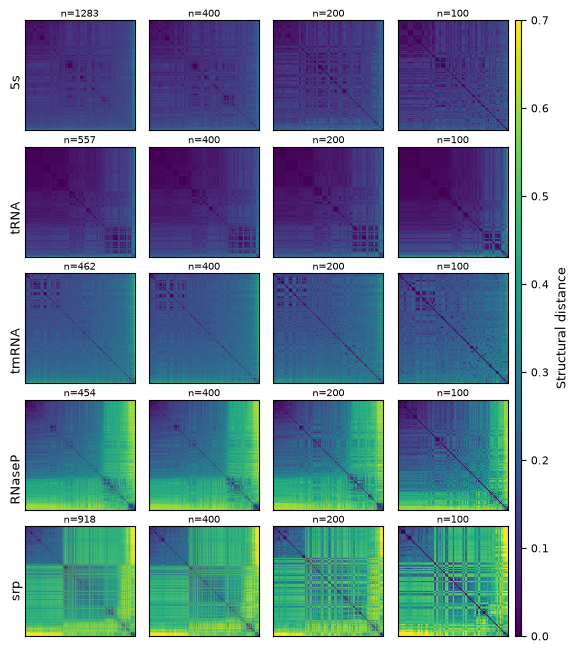

In [25]:
plot_matrices_sort_ids(
    selected_fams,
    ids_by_strategy["randS"],
    dist_mat,
)

## strategy: sortS

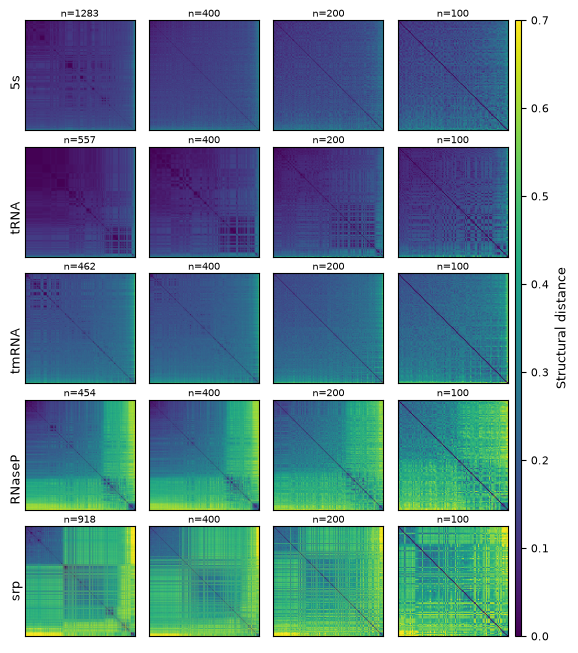

In [32]:
plot_matrices_sort_ids(
    selected_fams,
    ids_by_strategy["sortS"],
    dist_mat, 
    save=True, 
)

## strategy: clusS

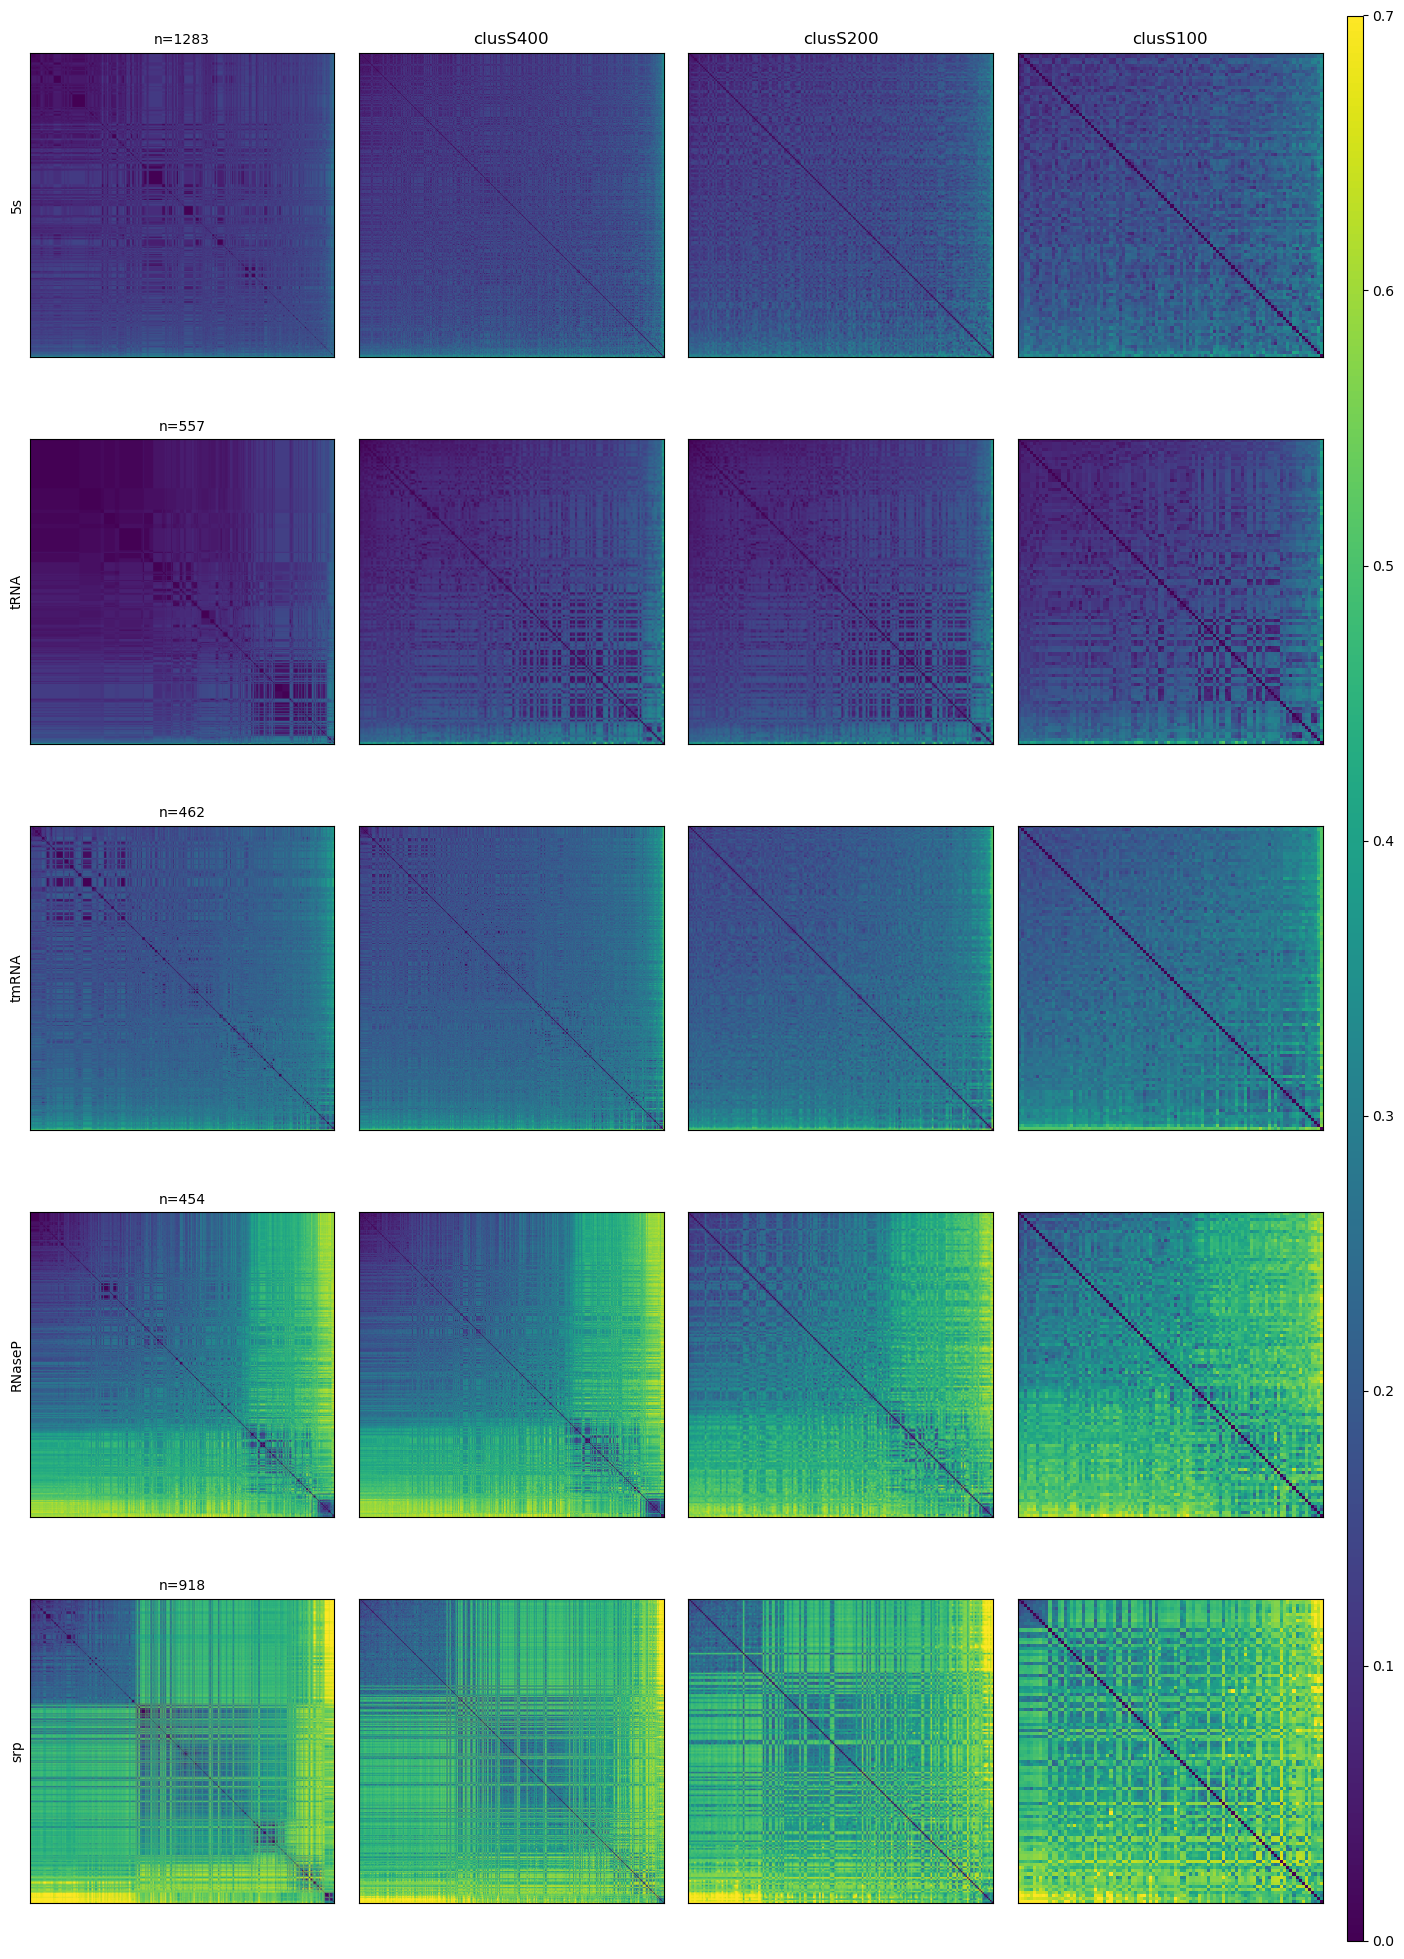

In [12]:
plot_matrices_sort_ids(
    selected_fams,
    ids_by_strategy["clusS"],
    dist_mat,
)